# BigVul EDA and the CWE decision gate

Issue #15. This notebook characterises the vulnerable functions that survive filtering and
decides whether the CWEs chosen in the plan (CWE-119 and CWE-125) leave enough samples.

**Data source.** The `bstee615/bigvul` mirror on Hugging Face, three Parquet files in
`data/raw/bigvul_hf/`. It carries the pre-fix and post-fix function bodies but no flaw-line
columns, so flaw lines are the lines of the pre-fix body that the fix deleted or changed.

Re-run from the repository root with:

```bash
pip install -e ".[notebook]"
jupyter execute --inplace notebooks/01_eda.ipynb
```

In [1]:
import os
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

if Path.cwd().name == "notebooks":
    os.chdir("..")

from soren.config import load_yaml
from soren.data.bigvul import load_bigvul
from soren.data.eda import (
    attrition_by_cwe,
    dataset_summary,
    first_flaw_positions,
    position_summary,
    relative_flaw_positions,
    vulnerable_cwe_counts,
)
from soren.data.filtering import FilterConfig, filter_bigvul

FIGURES = Path("notebooks/figures")
FIGURES.mkdir(parents=True, exist_ok=True)
plt.rcParams.update({"figure.dpi": 110, "axes.spines.top": False, "axes.spines.right": False})
pd.set_option("display.float_format", "{:.3f}".format)

settings = load_yaml("configs/data.yaml")
BOUNDS = {"min_lines": settings["min_lines"], "max_lines": settings["max_lines"]}
raw = load_bigvul("data/raw/bigvul_hf")
print(
    f"{len(raw):,} functions, {int(raw['vul'].sum()):,} vulnerable, "
    f"{raw['project'].nunique()} projects"
)

217,007 functions, 10,895 vulnerable, 309 projects


## 1. Which CWEs are there?

Vulnerable functions per CWE, before any other filter.

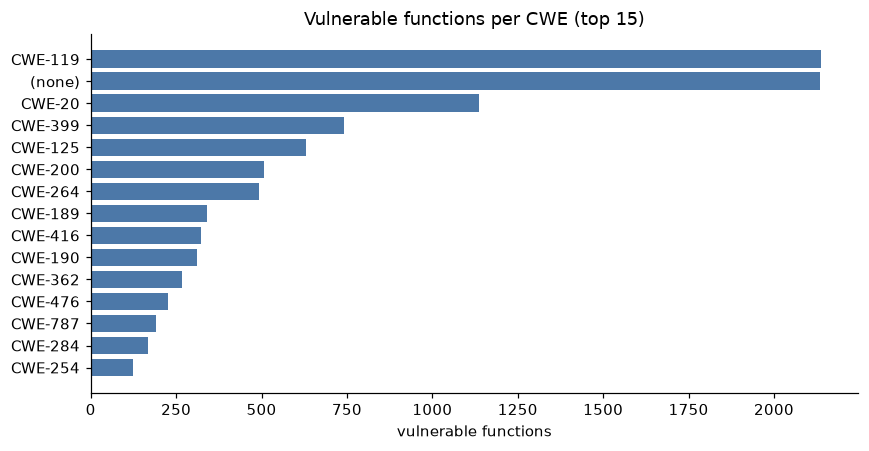

,vulnerable functions
cwe,
CWE-119,2139
(none),2135
CWE-20,1136
CWE-399,742
CWE-125,630
CWE-200,508
CWE-264,493
CWE-189,341
CWE-416,323


In [2]:
counts = vulnerable_cwe_counts(raw)
top = counts.head(15)
fig, ax = plt.subplots(figsize=(8, 4.2))
ax.barh(top.index[::-1], top.values[::-1], color="#4c78a8")
ax.set_xlabel("vulnerable functions")
ax.set_title("Vulnerable functions per CWE (top 15)")
fig.tight_layout()
fig.savefig(FIGURES / "cwe_counts.png")
plt.show()
counts.head(15).to_frame("vulnerable functions")

## 2. How many survive filtering, per CWE?

Each column filters one CWE on its own. Steps, in order: has flaw lines (the fix deleted or
changed at least one line), has a flaw line that carries code, line count within bounds,
de-duplicated.

In [3]:
FAMILY = ["CWE-119", "CWE-120", "CWE-125", "CWE-787"]
candidates = list(dict.fromkeys([*FAMILY, *[c for c in counts.index[:8] if c != "(none)"]]))
attrition = attrition_by_cwe(raw, candidates, FilterConfig(**BOUNDS))
attrition.loc["kept (share)"] = attrition.loc["deduplicated"] / attrition.loc["selected_cwes"].clip(
    lower=1
)
attrition

,CWE-119,CWE-120,CWE-125,CWE-787,CWE-20,CWE-399,CWE-200,CWE-264,CWE-189
selected_cwes,2139.000,9.000,630.000,191.000,1136.000,742.000,508.000,493.000,341.000
has_flaw_lines,1620.000,5.000,446.000,159.000,854.000,585.000,333.000,365.000,258.000
has_code_flaw_lines,1600.000,5.000,444.000,159.000,847.000,582.000,333.000,363.000,255.000
line_count,1484.000,5.000,383.000,149.000,782.000,543.000,307.000,348.000,228.000
deduplicated,1251.000,4.000,328.000,126.000,665.000,451.000,259.000,293.000,190.000
kept (share),0.585,0.444,0.521,0.660,0.585,0.608,0.510,0.594,0.557


## 3. The decision gate

The plan's rule: if fewer than about 1,000 usable functions survive for CWE-119 and CWE-125,
widen to the memory-safety family (CWE-119, 120, 125, 787) and treat it as one category.

In [4]:
def usable(cwes):
    frame, log = filter_bigvul(raw, FilterConfig(cwes=list(cwes), **BOUNDS))
    return frame, log


planned, planned_log = usable(["CWE-119", "CWE-125"])
family, family_log = usable(FAMILY)
gate = pd.DataFrame(
    {
        "CWE-119 + CWE-125": {e["step"]: e["rows"] for e in planned_log},
        "memory-safety family": {e["step"]: e["rows"] for e in family_log},
    }
)
print("usable functions, planned CWEs:", len(planned))
print("usable functions, family:      ", len(family))
print(family["cwe"].value_counts().to_string())
gate

usable functions, planned CWEs: 1578
usable functions, family:       1708
cwe
CWE-119    1251
CWE-125     327
CWE-787     126
CWE-120       4


,CWE-119 + CWE-125,memory-safety family
loaded,217007,217007
vulnerable,10895,10895
selected_cwes,2769,2969
has_flaw_lines,2066,2230
has_code_flaw_lines,2044,2208
line_count,1867,2021
deduplicated,1578,1708


In [5]:
CHOSEN = settings["cwes"]
filtered, log = usable(CHOSEN)
print("configured CWEs:", CHOSEN, "->", len(filtered), "usable functions")
dataset_summary(filtered).to_frame("value")

configured CWEs: ['CWE-119', 'CWE-125'] -> 1578 usable functions


,value
functions,1578.000
projects,116.000
fixing commits,581.000
median lines,38.000
mean lines,61.080
median flaw lines,2.000
mean flaw lines,6.158
single flaw line (share),0.414
largest project (share),0.224


## 4. Function length

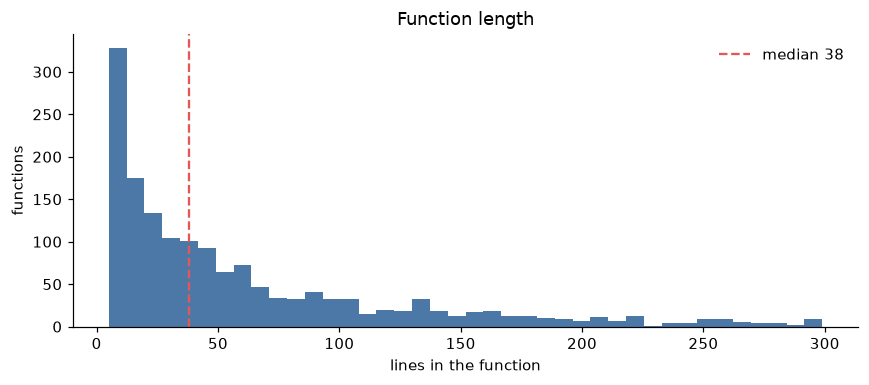

,count,mean,std,min,25%,50%,75%,max
lines,1578.000,61.080,63.442,5.000,15.000,38.000,85.000,299.000


In [6]:
fig, ax = plt.subplots(figsize=(8, 3.6))
ax.hist(filtered["num_lines"], bins=40, color="#4c78a8")
ax.axvline(
    filtered["num_lines"].median(),
    color="#e45756",
    linestyle="--",
    label=f"median {filtered['num_lines'].median():.0f}",
)
ax.set_xlabel("lines in the function")
ax.set_ylabel("functions")
ax.set_title("Function length")
ax.legend(frameon=False)
fig.tight_layout()
fig.savefig(FIGURES / "function_length.png")
plt.show()
filtered["num_lines"].describe().to_frame("lines").T

## 5. Flaw lines per function

Functions with several flaw lines have several acceptable answers, which makes them easier to
localize.

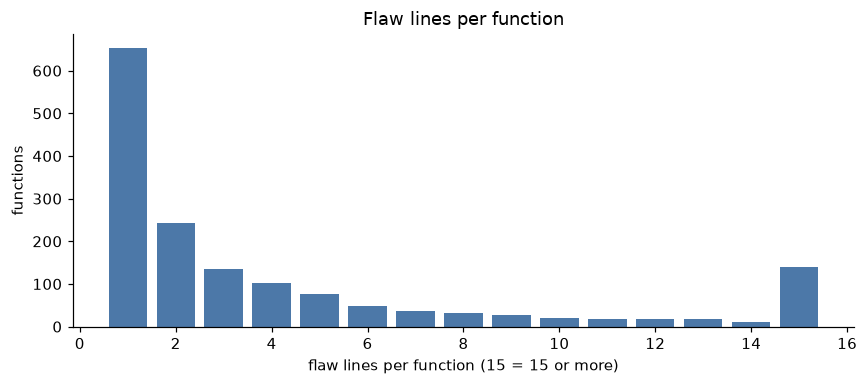

single flaw line: 41.4% of functions
median share of a function's lines that are flaw lines: 7.7%


,count,mean,std,min,25%,50%,75%,max
flaw lines,1578.000,6.158,14.074,1.000,1.000,2.000,5.000,198.000


In [7]:
flaw_counts = filtered["flaw_line_indices"].map(len)
clipped = flaw_counts.clip(upper=15)
fig, ax = plt.subplots(figsize=(8, 3.6))
ax.bar(*np.unique(clipped, return_counts=True), color="#4c78a8")
ax.set_xlabel("flaw lines per function (15 = 15 or more)")
ax.set_ylabel("functions")
ax.set_title("Flaw lines per function")
fig.tight_layout()
fig.savefig(FIGURES / "flaw_lines_per_function.png")
plt.show()
share = flaw_counts / filtered["num_lines"]
print(f"single flaw line: {(flaw_counts == 1).mean():.1%} of functions")
print(f"median share of a function's lines that are flaw lines: {share.median():.1%}")
flaw_counts.describe().to_frame("flaw lines").T

## 6. Where in the function are the flaw lines?

This matters for evaluation. If flaw lines cluster at a typical position, a policy can score
well from position alone, and reading the function top to bottom becomes a strong baseline.
0 is the first line of the function, 1 the last.

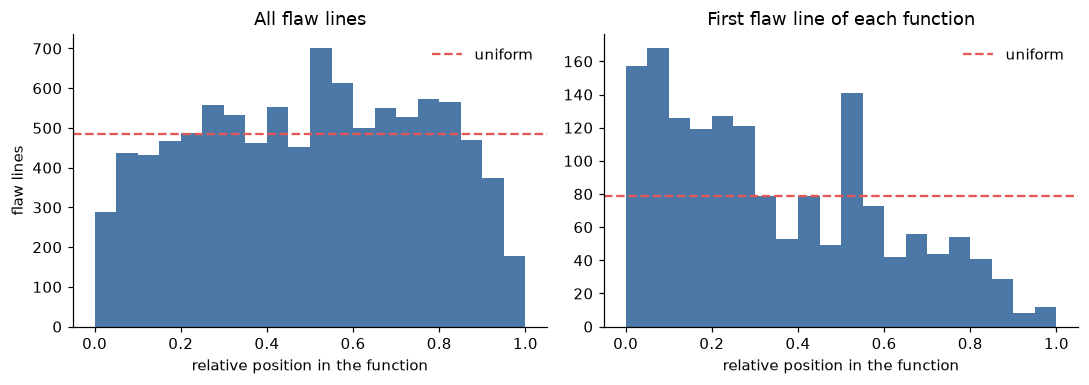

mean position, all flaw lines: 0.499 (uniform would be 0.500)
mean position, first flaw line: 0.346


,from,to,share,uniform
0,0.000,0.100,0.075,0.100
1,0.100,0.200,0.092,0.100
2,0.200,0.300,0.107,0.100
3,0.300,0.400,0.102,0.100
4,0.400,0.500,0.103,0.100
5,0.500,0.600,0.135,0.100
6,0.600,0.700,0.108,0.100
7,0.700,0.800,0.113,0.100
8,0.800,0.900,0.106,0.100
9,0.900,1.000,0.057,0.100


In [8]:
all_positions = relative_flaw_positions(filtered)
first_positions = first_flaw_positions(filtered)
fig, axes = plt.subplots(1, 2, figsize=(10, 3.6), sharey=False)
for ax, values, title in [
    (axes[0], all_positions, "All flaw lines"),
    (axes[1], first_positions, "First flaw line of each function"),
]:
    ax.hist(values, bins=20, range=(0, 1), color="#4c78a8")
    ax.axhline(len(values) / 20, color="#e45756", linestyle="--", label="uniform")
    ax.set_xlabel("relative position in the function")
    ax.set_title(title)
    ax.legend(frameon=False)
axes[0].set_ylabel("flaw lines")
fig.tight_layout()
fig.savefig(FIGURES / "flaw_line_positions.png")
plt.show()
print(f"mean position, all flaw lines: {all_positions.mean():.3f} (uniform would be 0.500)")
print(f"mean position, first flaw line: {first_positions.mean():.3f}")
position_summary(all_positions)

In [9]:
# How far would reading top to bottom get? Lines read before the first flaw line, as a share.
print(
    f"median share of the function read before the first flaw line: {np.median(first_positions):.1%}"
)
print(
    f"first flaw line in the first quarter of the function: {(first_positions < 0.25).mean():.1%}"
)
print(f"first flaw line in the last quarter: {(first_positions >= 0.75).mean():.1%}")

median share of the function read before the first flaw line: 28.6%
first flaw line in the first quarter of the function: 44.2%
first flaw line in the last quarter: 9.1%


## 7. Projects

A handful of projects dominate BigVul, which is a generalisation risk.

In [10]:
projects = filtered["project"].value_counts()
print(
    f"{len(projects)} projects; the top 5 hold {projects.head(5).sum() / len(filtered):.1%} of functions"
)
projects.head(10).to_frame("functions").assign(share=lambda t: t["functions"] / len(filtered))

116 projects; the top 5 hold 62.6% of functions


,functions,share
project,,
Android,353,0.224
Chrome,344,0.218
linux,149,0.094
tcpdump,95,0.060
ImageMagick,47,0.030
iperf,43,0.027
FFmpeg,39,0.025
radare2,31,0.020
ghostscript,28,0.018


## 8. Findings and decision

Numbers from the run on 2026-10-05, against the full mirror (217,007 functions, 10,895 vulnerable).

**Decision: keep CWE-119 and CWE-125.** They leave **1,578** usable functions (1,251 and 327),
above the 1,000 threshold, so the plan's choice stands and the two CWEs stay separate
categories. Widening to the memory-safety family would add only 130 functions (126 from
CWE-787, 4 from CWE-120). It remains available as a fallback if CFG extraction and label
alignment remove more than about a third of the 1,578.

What the rest of the project should take from this:

- **About 43% of vulnerable functions are lost before any modelling.** 25% have no flaw line
  because the fix only added code; another 15% of the remainder are duplicates.
- **Reading top to bottom is a strong baseline.** All flaw lines together are spread almost
  uniformly (mean position 0.499), but the *first* flaw line of a function comes early: it is
  in the first quarter of the function 44% of the time, and half the time it is reached after
  reading 29% of the lines. `LineOrder` must be reported next to the agent, and the
  relative-position feature must be ablated.
- **Most functions have several acceptable answers.** Only 41% have a single flaw line; the
  median is 2 and the mean 6.2, with a tail up to 198 where the fix rewrote most of the
  function. Results should be broken down by single versus multiple flaw lines, and a cap on
  the share of a function's lines that are flaw lines is worth considering.
- **Functions are small.** Median 38 lines, 75% under 85, so most CFGs will be well within the
  200-step budget.
- **A few projects dominate.** Android and Chrome hold 44% of the functions and the top five
  hold 63%. The split is by fixing commit (581 commits), not by project, so a per-project
  breakdown is needed to see whether results generalise.
- **2,135 vulnerable functions carry no CWE** and are unusable for a per-CWE study.

Caveat: this is the Hugging Face mirror, not the authors' CSV. Its vulnerable count (10,895)
matches the roughly 10,900 reported in the BigVul paper, but its total (217,007) is higher than
the paper's 188,636, so the non-vulnerable rows differ. Only vulnerable rows are used here.